# Discovery Notebook - PEAD Data Exploration

Helper functions for calculating CAR, loading data, and examining single-stock behavior around earnings announcement dates.


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
from typing import Optional, Tuple
import matplotlib.pyplot as plt

%matplotlib inline

# Config
DB_FILE = Path("db.h5")
H5_STOCKS = "sp400"
H5_MACRO = "macros"
IJH_TICKER = "IJH"

## 1. Loading Helpers

In [10]:
def load_ticker(ticker: str, start: str = None, end: str = None) -> pd.DataFrame:
    """
    Load historical OHLCV for a single ticker from the local HDF5 database.
    
    Args:
        ticker: Stock ticker (e.g., 'AAPL')
        start:  Optional start date ('YYYY-MM-DD')
        end:    Optional end date ('YYYY-MM-DD')
    """
    path = f"/{H5_STOCKS}/{ticker}"
    df = pd.read_hdf(DB_FILE, path)
    
    if start:
        df = df[df["Date"] >= pd.to_datetime(start)]
    if end:
        df = df[df["Date"] <= pd.to_datetime(end)]
    
    return df.sort_values("Date").reset_index(drop=True)

def load_ijh(start: str = None, end: str = None) -> pd.DataFrame:
    """Load IJH (S&P Mid-Cap 400 ETF) benchmark data."""
    path = f"/{H5_MACRO}/{IJH_TICKER}"
    df = pd.read_hdf(DB_FILE, path)
    
    if start:
        df = df[df["Date"] >= pd.to_datetime(start)]
    if end:
        df = df[df["Date"] <= pd.to_datetime(end)]
    
    return df.sort_values("Date").reset_index(drop=True)

def get_ticker_list() -> list:
    """Return all tickers stored in the sp400 group."""
    with pd.HDFStore(DB_FILE, mode="r") as store:
        keys = store.keys()
    return sorted([k.split("/")[-1] for k in keys if f"/{H5_STOCKS}/" in k])

## 2. Calculate Log Returns & CAR

In [11]:
def calc_log_return(df: pd.DataFrame, price_col: str = "Close") -> pd.Series:
    """Daily log returns: ln(Price_t / Price_{t-1})"""
    prices = df[price_col]
    return np.log(prices / prices.shift(1))

def calc_abnormal_return(stock_df: pd.DataFrame, ijh_df: pd.DataFrame) -> pd.Series:
    """
    Abnormal returns: AR = ln(Stock_t/Stock_{t-1}) - ln(IJH_t/IJH_{t-1})
    """
    stock_ret = calc_log_return(stock_df)
    ijh_ret = calc_log_return(ijh_df)
    return stock_ret - ijh_ret

def calc_car(stock_df: pd.DataFrame, ijh_df: pd.DataFrame, 
             event_date: str, horizon_days: int = 10) -> float:
    """
    Cumulative Abnormal Return (CAR) from T+1 to T+horizon_days.
    
    Args:
        stock_df:      Stock price DataFrame
        ijh_df:        IJH benchmark DataFrame
        event_date:    Announcement date ('YYYY-MM-DD')
        horizon_days:  Holding period (default 10 for T+1 to T+11)
    """
    merged = pd.merge(stock_df, ijh_df, on="Date", suffixes=('_stock', '_ijh'))
    merged = merged.sort_values("Date").reset_index(drop=True)
    
    merged["ar"] = calc_abnormal_return(
        merged[["Date", "Close_stock"]].rename(columns={"Close_stock": "Close"}),
        merged[["Date", "Close_ijh"]].rename(columns={"Close_ijh": "Close"})
    )
    
    event_dt = pd.to_datetime(event_date)
    post_event = merged[merged["Date"] > event_dt]
    holding_period = post_event.head(horizon_days)
    
    return holding_period["ar"].sum()

In [ ]:
def plot_event_window(ticker: str, event_date: str, days_before: int = 5, days_after: int = 10):
    """
    Plot price % change and volume around an event date.

    Args:
        ticker: Stock ticker to analyze
        event_date: Event date in 'YYYY-MM-DD' format
        days_before: Days before event to show (default 5)
        days_after: Days after event to show (default 10)
    """
    # Load data
    stock = load_ticker(ticker)
    ijh = load_ijh()
    event_dt = pd.to_datetime(event_date)

    # Find the index position of the event date in stock data
    stock_event_idx = stock[stock["Date"] >= event_dt].index[0] if any(stock["Date"] >= event_dt) else len(stock) - 1
    ijh_event_idx = ijh[ijh["Date"] >= event_dt].index[0] if any(ijh["Date"] >= event_dt) else len(ijh) - 1

    # Get window
    start_idx = max(0, stock_event_idx - days_before)
    end_idx = min(len(stock) - 1, stock_event_idx + days_after)
    stock_window = stock.iloc[start_idx:end_idx + 1].copy()

    start_idx_ijh = max(0, ijh_event_idx - days_before)
    end_idx_ijh = min(len(ijh) - 1, ijh_event_idx + days_after)
    ijh_window = ijh.iloc[start_idx_ijh:end_idx_ijh + 1].copy()

    # Calculate % change from event date
    stock_event_price = stock_window[stock_window["Date"] >= event_dt]["Close"].iloc[0] if any(stock_window["Date"] >= event_dt) else stock_window["Close"].iloc[-1]
    stock_window["Pct_Change"] = (stock_window["Close"] / stock_event_price - 1) * 100

    ijh_event_price = ijh_window[ijh_window["Date"] >= event_dt]["Close"].iloc[0] if any(ijh_window["Date"] >= event_dt) else ijh_window["Close"].iloc[-1]
    ijh_window["Pct_Change"] = (ijh_window["Close"] / ijh_event_price - 1) * 100

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Plot price % change
    ax1.plot(range(len(stock_window)), stock_window["Pct_Change"],
            label=f"{ticker}", linewidth=2, color="blue")
    ax1.plot(range(len(ijh_window)), ijh_window["Pct_Change"],
            label="IJH (S&P Mid-Cap 400)", linewidth=2, color="orange", linestyle="--")

    # Event line
    event_x = stock_window[stock_window["Date"] >= event_dt].index[0] - stock_window.index[0]
    ax1.axvline(x=event_x, color="red", linestyle=":", alpha=0.7, label=f"Event Date({event_date})")
    ax1.axhline(y=0, color="gray", linestyle="-", alpha=0.3)

    ax1.set_ylabel("% Change from Event", fontsize=12)
    ax1.set_title(f"{ticker} vs IJH Event Window ({event_date})", fontsize=14, fontweight="bold")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Format x-axis
    tick_positions = range(0, len(stock_window), max(1, len(stock_window) // 10))
    tick_labels = [stock_window.iloc[i]["Date"].strftime("%m/%d") for i in tick_positions]
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels([])

    # Plot volume as bar chart
    ax2.bar(range(len(stock_window)), stock_window["Volume"], color="steelblue", alpha=0.6)
    ax2.axvline(x=event_x, color="red", linestyle=":", alpha=0.7)
    ax2.set_ylabel("Volume", fontsize=12)
    ax2.set_xlabel("Trading Days", fontsize=12)

    # Format x-axis with dates
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(tick_labels, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    return fig, (ax1, ax2)

# Example usage:
# plot_event_window("AAPL", "2025-01-15")


## Helper to calculate Metrics for verification

In [ ]:
# =============================================================================
# 1. PRE-EVENT MOMENTUM (Mom_5D)
# =============================================================================

def calc_momentum_5d(df: pd.DataFrame, event_date: str, price_col: str = "Close") -> float:
    """
    Pre-event momentum: percentage change from T-5 to T.

    Formula: Mom_5D = (Close_T / Close_{T-5}) - 1
    """
    event_dt = pd.to_datetime(event_date)

    # Find closest trading day <= event_date for T
    t_idx = df[df["Date"] <= event_dt].index[-1]

    # T-5
    t_minus_5_idx = max(0, t_idx - 5)

    close_t = df.loc[t_idx, price_col]
    close_t_5 = df.loc[t_minus_5_idx, price_col]

    return (close_t / close_t_5) - 1


# =============================================================================
# 2. CUMULATIVE ABNORMAL RETURN (CAR)
# =============================================================================

def calc_car(stock_df: pd.DataFrame, index_df: pd.DataFrame,
            event_date: str, hold_days: int = 10) -> float:
    """
    Cumulative Abnormal Return over T+1 to T+hold_days.

    Formula: CAR = sum[ ln(Stock_t/Stock_{t-1}) - ln(Index_t/Index_{t-1}) ]
    """
    event_dt = pd.to_datetime(event_date)

    # Get T index in stock data
    t_stock_idx = stock_df[stock_df["Date"] <= event_dt].index[-1]

    # Holding period: T+1 to T+hold_days
    start_idx = t_stock_idx + 1
    end_idx = min(start_idx + hold_days, len(stock_df) - 1)
    stock_hold = stock_df.iloc[start_idx:end_idx].copy().reset_index(drop=True)

    # Get corresponding index period
    t_index_idx = index_df[index_df["Date"] <= event_dt].index[-1]
    idx_start = t_index_idx + 1
    idx_end = min(idx_start + hold_days, len(index_df) - 1)
    idx_hold = index_df.iloc[idx_start:idx_end].copy().reset_index(drop=True)

    # Log returns
    stock_log_ret = np.log(stock_hold["Close"] / stock_hold["Close"].shift(1))
    idx_log_ret = np.log(idx_hold["Close"] / idx_hold["Close"].shift(1))

    # Sum abnormal returns
    car = (stock_log_ret - idx_log_ret).sum()

    return car


# =============================================================================
# 3. MARKET-ADJUSTED MAXIMUM DRAWDOWN (MaxDD_MA)
# =============================================================================

def calc_maxdd_ma(stock_df: pd.DataFrame, index_df: pd.DataFrame,
                    event_date: str, hold_days: int = 10) -> float:
    """
    Worst market-adjusted drawdown during holding period.

    Formula: MaxDD_MA = min[ (Stock_t/Stock_T - 1) - (Index_t/Index_T - 1) ]
    """
    event_dt = pd.to_datetime(event_date)

    # T (event day) prices
    t_stock_idx = stock_df[stock_df["Date"] <= event_dt].index[-1]
    t_index_idx = index_df[index_df["Date"] <= event_dt].index[-1]

    price_stock_t = stock_df.loc[t_stock_idx, "Close"]
    price_index_t = index_df.loc[t_index_idx, "Close"]

    # Holding period
    start_stock = t_stock_idx + 1
    end_stock = min(start_stock + hold_days, len(stock_df) - 1)
    stock_hold = stock_df.iloc[start_stock:end_stock].copy()

    start_idx = t_index_idx + 1
    end_idx = min(start_idx + hold_days, len(index_df) - 1)
    idx_hold = index_df.iloc[start_idx:end_idx].copy()

    # Percentage change from T
    stock_pct = (stock_hold["Close"].values / price_stock_t) - 1
    idx_pct = (idx_hold["Close"].values / price_index_t) - 1

    # Market-adjusted path
    ma_path = stock_pct - idx_pct

    return ma_path.min()


# =============================================================================
# 4. VOLUME FOOTPRINT (Gate 2)
# =============================================================================

def calc_volume_ratio(stock_df: pd.DataFrame, event_date: str,
                        ma_window: int = 20, event_window: int = 3) -> float:
    """
    Compare event-period volume to rolling average.

    Formula: (Volume_T + Volume_{T+1} + Volume_{T+2}) / 3  >  2.0 × Rolling 20D MA
    Returns the ratio (not boolean).
    """
    event_dt = pd.to_datetime(event_date)
    t_idx = stock_df[stock_df["Date"] <= event_dt].index[-1]

    # Event window volume average (T to T+2)
    end_event_idx = min(t_idx + event_window, len(stock_df) - 1)
    event_volume = stock_df.iloc[t_idx:end_event_idx + 1]["Volume"].mean()

    # Rolling 20-day volume average (before event)
    start_ma_idx = max(0, t_idx - ma_window)
    ma_volume = stock_df.iloc[start_ma_idx:t_idx]["Volume"].mean()

    return event_volume / ma_volume if ma_volume > 0 else 0.0


# =============================================================================
# 5. VERIFICATION GATE COMBINED
# =============================================================================

def verify_pead_event(stock_df: pd.DataFrame, index_df: pd.DataFrame,
                    event_date: str, hold_days: int = 10) -> dict:
    """
    Run all 3 verification gates on a single event.

    Returns dict with all metrics and boolean pass/fail for each gate.
    """
    car = calc_car(stock_df, index_df, event_date, hold_days)
    maxdd = calc_maxdd_ma(stock_df, index_df, event_date, hold_days)
    vol_ratio = calc_volume_ratio(stock_df, event_date)

    # Gate conditions
    gate1 = car > 0.03
    gate2 = vol_ratio > 2.0
    gate3 = maxdd > -0.015

    return {
        "event_date": event_date,
        "car": car,
        "maxdd_ma": maxdd,
        "volume_ratio": vol_ratio,
        "gate1_pass": gate1,
        "gate2_pass": gate2,
        "gate3_pass": gate3,
        "is_true_pead": gate1 and gate2 and gate3,
    }


## 3. Exploration

In [12]:
# List available tickers
tickers = get_ticker_list()
print(f"Tickers in database: {len(tickers)}")
print(f"Sample: {', '.join(tickers[:5])}")

Tickers in database: 45
Sample: AA, AAL, AAON, ACI, ACM


In [103]:
# Load a specific stock
# ticker = tickers[0] if tickers else "AA"
ticker = 'BWA'
df = load_ticker(ticker)
ijh = load_ijh()

print(f"{ticker} - {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"IJH    - {len(ijh)} rows,  {ijh['Date'].min().date()} to {ijh['Date'].max().date()}")

df.head()

BWA - 3769 rows, 2011-06-16 to 2026-06-11
IJH    - 3769 rows,  2011-06-16 to 2026-06-11


,Date,Open,High,Low,Close,Volume
0,2011-06-16,25.470847,25.943479,25.111793,25.426881,2466710
1,2011-06-17,25.895849,26.580983,25.507485,26.203610,4696451
2,2011-06-20,26.115678,26.921718,25.950806,26.811803,3560905
3,2011-06-21,26.998658,27.844999,26.910726,27.683791,4165939
4,2011-06-22,27.625170,27.982759,27.496937,27.559221,2987680


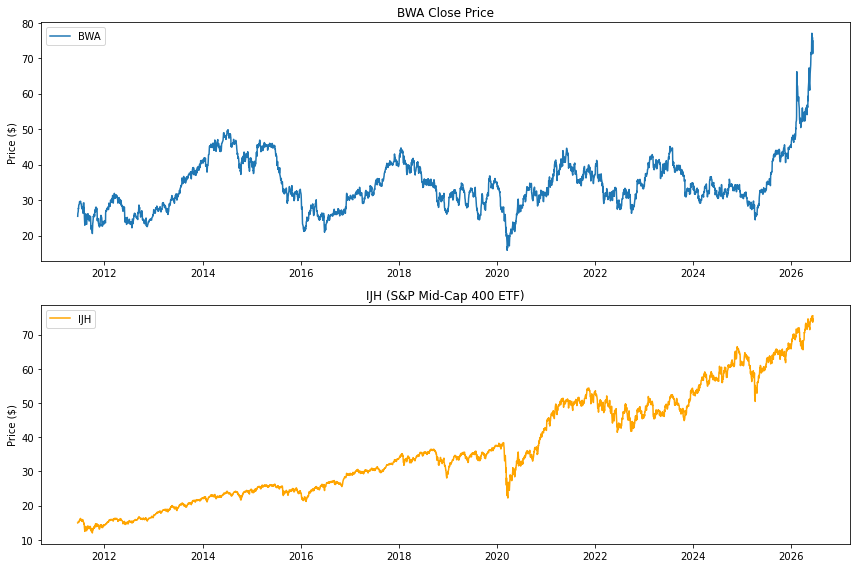

In [104]:
# Plot price history
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax1 = axes[0]
ax1.plot(df["Date"], df["Close"], label=ticker)
ax1.set_title(f"{ticker} Close Price")
ax1.set_ylabel("Price ($)")
ax1.legend()

ax2 = axes[1]
ax2.plot(ijh["Date"], ijh["Close"], label="IJH", color="orange")
ax2.set_title("IJH (S&P Mid-Cap 400 ETF)")
ax2.set_ylabel("Price ($)")
ax2.legend()

plt.tight_layout()
plt.show()

## 4. CAR Calculation Example

In [105]:
# Example: Assume earnings announced on Jan 15, 2025 for a stock
# We want CAR from T+1 (Jan 16) to T+11 (Jan 29)

event_date = "2025-01-15"

try:
    car = calc_car(df, ijh, event_date, horizon_days=10)
    print(f"CAR for {ticker} (event={event_date}, 10-day): {car:.4%}")
except Exception as e:
    print(f"Error: {e}")

CAR for BWA (event=2025-01-15, 10-day): -0.3553%


## 5. Rolling CAR Analysis

Calculate CAR for multiple date windows to see how the stock behaves.

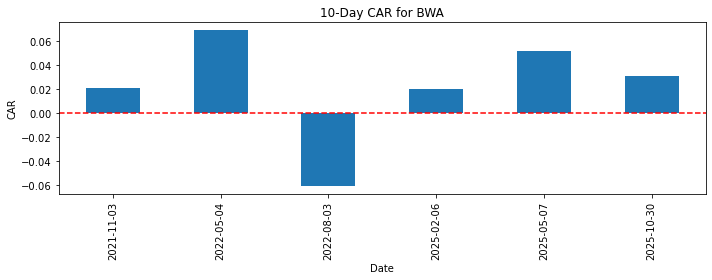

In [117]:
# Pick random dates or specific dates for CAR analysis
# test_dates = [
#     "2024-01-15",
#     "2024-04-15",
#     "2024-07-15",
#     "2024-10-15",
#     "2025-01-15",
# ]
test_dates = [
    '2021-11-03',
    '2022-05-04',
    '2022-08-03',
    '2025-02-06',
    '2025-05-07',
    '2025-10-30'
]

results = []
for date in test_dates:
    try:
        car_val = calc_car(df, ijh, date)
        results.append({"Date": date, "CAR": car_val})
    except Exception:
        pass

results_df = pd.DataFrame(results)
results_df.set_index("Date")["CAR"].plot(kind="bar", figsize=(10, 4))
plt.axhline(0, color="red", linestyle="--")
plt.title(f"10-Day CAR for {ticker}")
plt.ylabel("CAR")
plt.tight_layout()
plt.show()

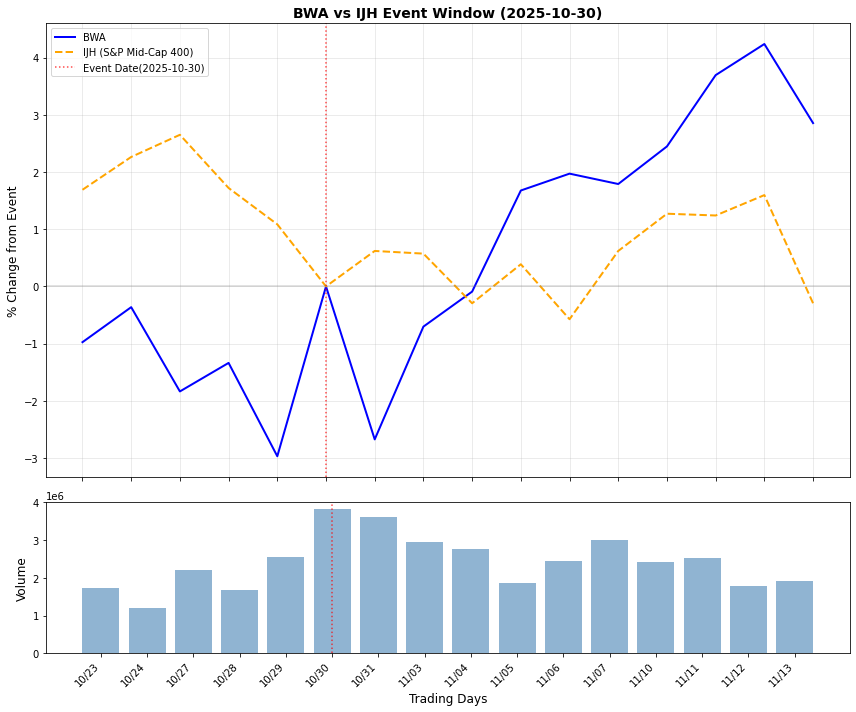

(<Figure size 864x720 with 2 Axes>,
 (<AxesSubplot:title={'center':'BWA vs IJH Event Window (2025-10-30)'}, ylabel='% Change from Event'>,
  <AxesSubplot:xlabel='Trading Days', ylabel='Volume'>))

In [121]:
plot_event_window(ticker, "2025-10-30")